# PhishGuard AI — Shakkya Sanketh (CIT-24-01-0573)
## NLP Pipeline — Phishing Email Detection
### Models: SVM (ML) | BiLSTM + Attention (DL)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")
print(f"Pandas:  {pd.__version__}")
print(f"Numpy:   {np.__version__}")

✅ All libraries imported!
Pandas:  3.0.3
Numpy:   2.4.4


In [23]:
# ── Load Dataset ─────────────────────────────────────────────
df = pd.read_csv('../data/phishing_email.csv')
df = df.rename(columns={'text_combined': 'email_text'})  # ← ADD THIS LINE

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded successfully!

Shape: (82486, 2)
Columns: ['email_text', 'label']


In [24]:
# ── Initial Exploration ───────────────────────────────────────
print("First 5 rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['label'].value_counts())
print(f"\nPhishing:   {df[df['label']==1].shape[0]:,}")
print(f"Legitimate: {df[df['label']==0].shape[0]:,}")

First 5 rows:


,email_text,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0



Data Types:
email_text      str
label         int64
dtype: object

Missing Values:
email_text    0
label         0
dtype: int64

Class Distribution:
label
1    42891
0    39595
Name: count, dtype: int64

Phishing:   42,891
Legitimate: 39,595


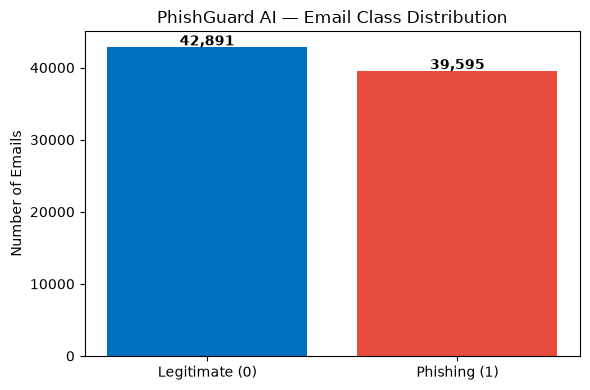

Chart saved to screenshots folder!


In [25]:
# ── Class Distribution Chart ──────────────────────────────────
plt.figure(figsize=(6, 4))
counts = df['label'].value_counts()
plt.bar(['Legitimate (0)', 'Phishing (1)'], 
        counts.values, 
        color=['#0070C0', '#E74C3C'])
plt.title('PhishGuard AI — Email Class Distribution')
plt.ylabel('Number of Emails')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png', dpi=150)
plt.show()
print("Chart saved to screenshots folder!")

In [26]:
from langdetect import detect, DetectorFactory
from tqdm import tqdm

DetectorFactory.seed = 0
tqdm.pandas()

def safe_detect(text):
    try:
        if len(str(text).strip()) < 10:
            return 'unknown'
        return detect(str(text))
    except:
        return 'unknown'

print("Detecting languages on full dataset...")
print("This takes 10-15 minutes — please wait...")
df['language'] = df['email_text'].progress_apply(safe_detect)

# Keep English only
df_english = df[df['language'] == 'en'].copy()
df_english = df_english.reset_index(drop=True)

print(f"\nOriginal dataset:      {len(df):,} emails")
print(f"English only:          {len(df_english):,} emails")
print(f"Removed:               {len(df) - len(df_english):,} non-English emails")
print(f"\nClass distribution after filtering:")
print(df_english['label'].value_counts())

# Replace df with english-only version
df = df_english
print("\ndf is now English-only and ready for preprocessing!")

Detecting languages on full dataset...
This takes 10-15 minutes — please wait...


100%|██████████| 82486/82486 [08:34<00:00, 160.33it/s]



Original dataset:      82,486 emails
English only:          80,757 emails
Removed:               1,729 non-English emails

Class distribution after filtering:
label
1    41763
0    38994
Name: count, dtype: int64

df is now English-only and ready for preprocessing!


In [27]:
# ── Preprocessing on English-Only Dataset ─────────────────────
# df already contains 80,757 English-only emails from previous cell
# NO re-loading needed — we continue from the filtered df

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
keep_words = {'not', 'no', 'never', 'won', 'free', 'urgent', 'verify'}
stop_words = stop_words - keep_words

def preprocess_email(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)
    text = re.sub(r'\S+@\S+', ' email ', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print(f"Preprocessing {len(df):,} English-only emails...")
print("Takes 3-5 minutes — please wait...")
df['cleaned_text'] = df['email_text'].apply(preprocess_email)
print("Done!")

print(f"\nTotal emails preprocessed: {len(df):,}")
print(f"Phishing:   {df[df['label']==1].shape[0]:,}")
print(f"Legitimate: {df[df['label']==0].shape[0]:,}")
print("\nBEFORE:", df['email_text'].iloc[0][:150])
print("\nAFTER: ", df['cleaned_text'].iloc[0][:150])

# Save preprocessed English-only dataset
df.to_csv('../data/phishing_email_preprocessed.csv', index=False)
print("\nPreprocessed dataset saved!")

Preprocessing 80,757 English-only emails...
Takes 3-5 minutes — please wait...
Done!

Total emails preprocessed: 80,757
Phishing:   41,763
Legitimate: 38,994

BEFORE: hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

AFTER:  hpl nom may see attached file hplno xl hplno xl

Preprocessed dataset saved!


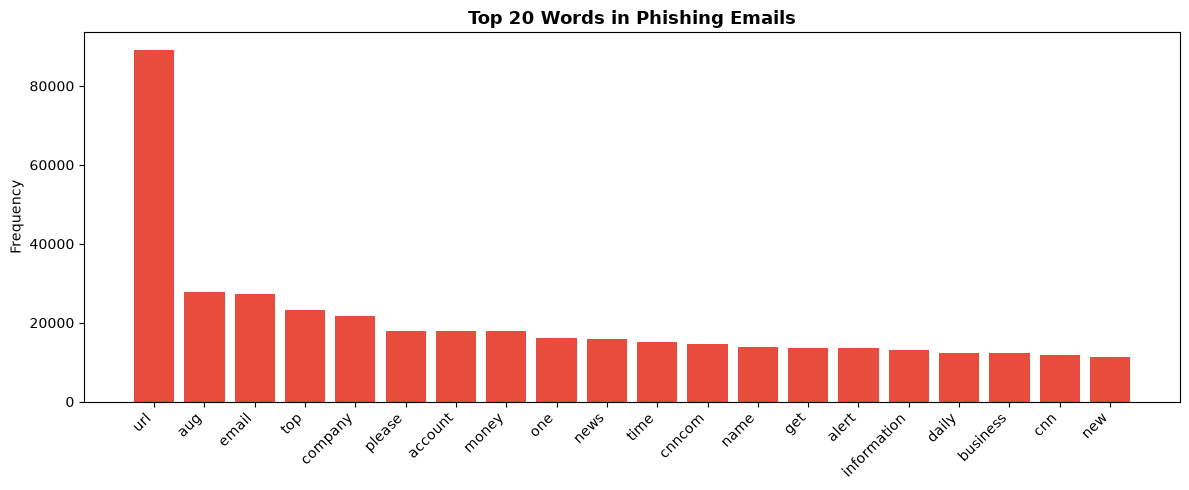

Chart saved!


In [28]:
from collections import Counter

# Top 20 words in phishing emails
phishing_text = ' '.join(df[df['label']==1]['cleaned_text'])
top_words = Counter(phishing_text.split()).most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(12,5))
plt.bar(words, counts, color='#E74C3C')
plt.title('Top 20 Words in Phishing Emails', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../screenshots/top_phishing_words.png', dpi=150)
plt.show()
print("Chart saved!")

Emails under 500 words: 77,740 out of 80,757


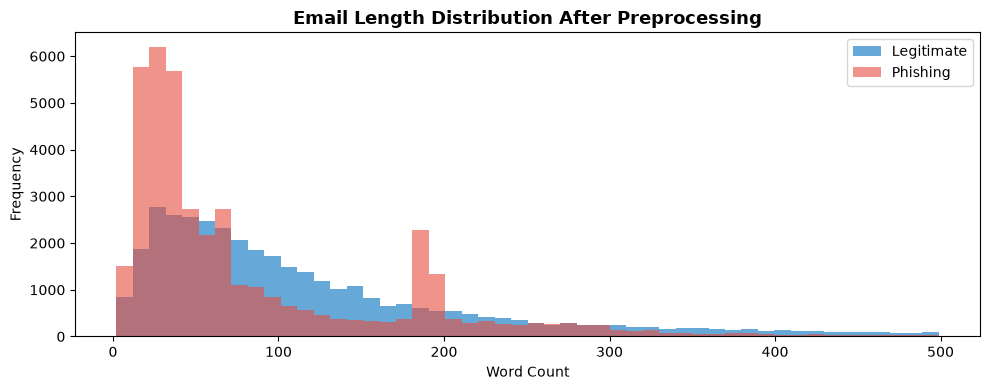


Average Phishing email length:   111 words
Average Legitimate email length: 176 words
Chart saved!


In [30]:
df['word_count'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

# Remove extreme outliers for better visualization (keep emails under 500 words)
df_plot = df[df['word_count'] < 500]

print(f"Emails under 500 words: {len(df_plot):,} out of {len(df):,}")

plt.figure(figsize=(10,4))
df_plot[df_plot['label']==0]['word_count'].plot(
    kind='hist', bins=50, alpha=0.6, label='Legitimate', color='#0070C0')
df_plot[df_plot['label']==1]['word_count'].plot(
    kind='hist', bins=50, alpha=0.6, label='Phishing', color='#E74C3C')

plt.title('Email Length Distribution After Preprocessing', fontsize=13, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/email_length_distribution.png', dpi=150)
plt.show()

# Print average lengths
print(f"\nAverage Phishing email length:   {df[df['label']==1]['word_count'].mean():.0f} words")
print(f"Average Legitimate email length: {df[df['label']==0]['word_count'].mean():.0f} words")
print("Chart saved!")

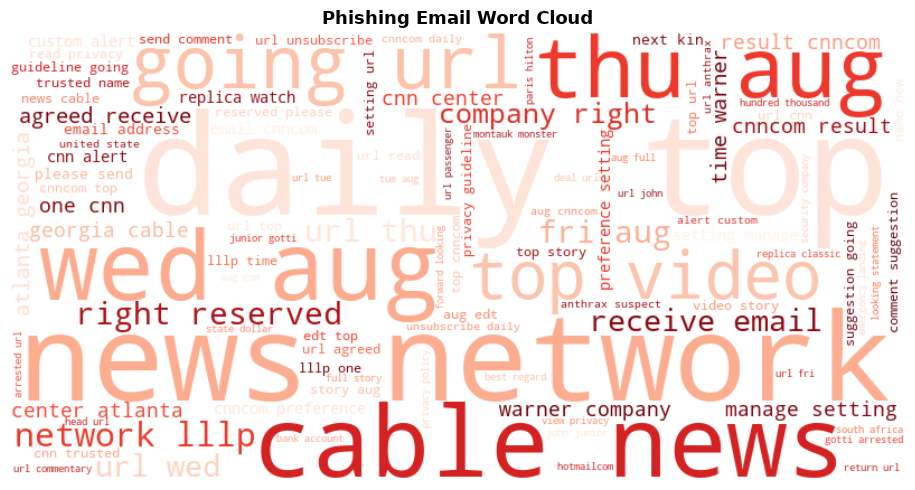

Chart saved!


In [31]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Reds', max_words=100).generate(phishing_text)
plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Phishing Email Word Cloud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/wordcloud_phishing.png', dpi=150)
plt.show()
print("Chart saved!")

Training samples: 64,605
Test samples:     16,152
TF-IDF features: 50,000

Training SVM — please wait...
Done!

===== SVM RESULTS =====
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      7799
    Phishing       0.99      0.99      0.99      8353

    accuracy                           0.99     16152
   macro avg       0.99      0.99      0.99     16152
weighted avg       0.99      0.99      0.99     16152

ROC-AUC: 0.9994


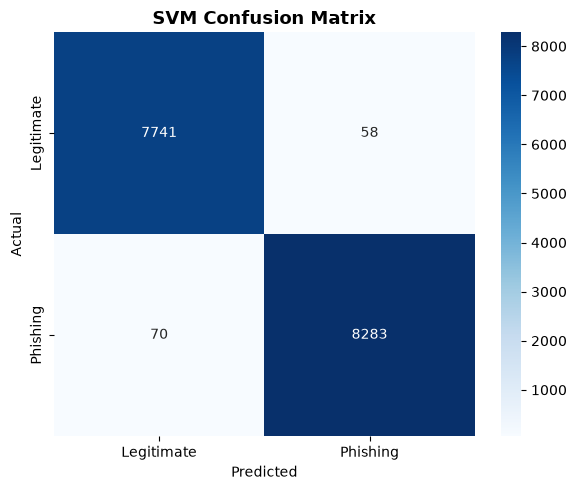


Models saved to models/ folder!


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import joblib

# ── Train/Test Split ─────────────────────────────────────────
X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")

# ── TF-IDF ───────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"TF-IDF features: {X_train_tfidf.shape[1]:,}")

# ── Train SVM ────────────────────────────────────────────────
print("\nTraining SVM — please wait...")
svm = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))
svm.fit(X_train_tfidf, y_train)
print("Done!")

# ── Evaluate ─────────────────────────────────────────────────
y_pred  = svm.predict(X_test_tfidf)
y_proba = svm.predict_proba(X_test_tfidf)[:,1]

print("\n===== SVM RESULTS =====")
print(classification_report(y_test, y_pred,
      target_names=['Legitimate','Phishing']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Phishing'],
            yticklabels=['Legitimate','Phishing'])
plt.title('SVM Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../screenshots/svm_confusion_matrix.png', dpi=150)
plt.show()

# ── Save Models ───────────────────────────────────────────────
joblib.dump(svm,   '../models/svm_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
print("\nModels saved to models/ folder!")